# Do three failures at one level make a signal? 📉
### The triple top & triple bottom — the textbook "three taps and reverse" figure, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

Here's a piece of chart lore you'll meet on day one of any technical-analysis course. When a stock falls to the **same price three times** and bounces each time — three valleys lined up at one level — that's a **triple bottom**, and it supposedly means the sellers are exhausted: the third failure to break lower is the tell, and when the price finally pops above the in-between highs (the *neckline*), you **buy the breakout** and ride the reversal. Flip it upside-down — three peaks at one level, then a break **down** — and you have a **triple top**, the bearish twin.

It's a *beautiful* story. Three is a magic number, the picture is clean, and "three failures = a wall" feels like real information. So let's do the thing the story never does: write down a **mechanical** rule for the figure, run it across two decades of real stocks, and ask whether buying the confirmed breakout actually beats just holding the stock.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data + honesty note up front.** Chart figures are **partly subjective** — three chartists will draw three different triangles on the same tape. We test the *closest mechanical definition* we can write down (three swing pivots at one price within a tolerance, real bounces between them, then a confirmed neckline break) and we say so. We use a fixed **30-name large-cap basket + SPY** (names still trading today), which carries **survivorship** — it can't include names that delisted after a failed pattern, a mild tilt *for* the bullish version. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from triple_top_bottom import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    asof = pd.Timestamp(ASOF)
    for f in PANEL:
        PANEL[f] = PANEL[f].loc[:asof]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real triple cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_bars': 5385, 'n_names': 30, 'fingerprint': '62992380d9e9', 'n_bottom': 356, 'n_top': 211, 'spy_bottom': 5, 'spy_top': 3, 'bottom': [(5, 356, 0.335, 0.644, 56, 1.75, 1.82, 0.369, 0.235), (10, 355, 0.207, 0.816, 53, 0.72, 0.77, 0.443, 0.107), (20, 354, 0.389, 1.6, 55, 0.79, 0.86, 0.421, 0.289), (40, 350, -0.689, 1.687, 48, -1.22, -1.32, 0.598, -0.789)], 'top': [(5, 211, -0.05, -0.36, 54, -0.15, 0.51), (10, 211, -0.59, -1.202, 48, -1.18, 0.626), (20, 210, -1.376, -2.598, 43, -2.04, 0.701), (40, 210, -1.941, -4.336, 46, -2.12, 0.703)], 'spy': [(5, 5, 0.161, 0.398, 0.92, 0.457), (10, 5, -0.089, 0.381, -0.11, 0.559), (20, 5, 0.281, 1.218, 0.15, 0.475), (40, 5, 0.699, 2.546, 0.46, 0.434)], 'robust': [(0.03, 0.07, 126, 0.322, 0.87, 0.424), (0.04, 0.05, 356, 0.335, 1.75, 0.367), (0.06, 0.04, 641, 0.018, 0.13, 0.492)], 'syn': [(0.0, 160, 218, 218, -1.64, -5.06, 0.828, 38), (0.2, 160, 209, 209, 5.02, 10.19, 0.016, 77)], 'cost_bps': 5.0}


real triple cache present: True | names: 30 | bars: 5385


## The answer first

| Question | Answer |
|---|---|
| After a confirmed **triple bottom**, does the stock outrun its own normal drift? | **Barely, and not reliably.** The best horizon (5 days) shows **+0.34%** excess — but at *t* = **1.75**, *under* the bar, and a random-date placebo matches it about **37%** of the time. By 40 days it's **negative**. |
| Is the magic-three threshold special? | **No.** Loosen or tighten the "same level" tolerance and the tiny edge **evaporates** — it's a knob-tuning artefact, not a wall. |
| Does the bearish **triple top** mirror it (a clean short)? | **No — it's worse.** Shorting the triple-top breakdown **loses** money on average (the names keep drifting **up** — short excess **-1.38%** at 20d). The figure does **not** reverse symmetrically. |
| So is it a tradable signal? | **No.** A thin, sub-*t*-2, knob-sensitive edge that **dies at costs** and **flips negative** at the horizons the lore actually recommends. |

> The picture is real on the chart; the *edge* is not. "Three failures at one level" is a pattern your eye loves and the tape ignores.

## 1 · The claim

> *"When price tests the same support **three** times and holds, the down-move is exhausted. The third failure is the confirmation. Buy when it breaks the neckline and ride the reversal — and short the mirror-image triple top when it breaks down."*

This is straight out of the canon — Edwards & Magee's *Technical Analysis of Stock Trends* (1948), Schabacker before them, and every modern pattern guide since (Bulkowski's *Encyclopedia of Chart Patterns* even tallies "success rates"). The triple top/bottom is sold as a **major reversal** figure: rarer than the double, and therefore *more* reliable because the level has been defended three times. The question isn't whether the picture exists — of course three bounces sometimes line up — it's whether **acting on the confirmed breakout pays.**

## 2 · So what?

If the figure worked, it would be a gift: a **visual, rules-light** entry that any retail trader can spot, with a built-in stop (just below the third bottom) and a clean target (the figure's height projected from the neckline). A reliable reversal signal you can *see* would be one of the great free lunches.

But two traps hide here. **(1) Selection by eye.** "Three taps at one level" is so loose that *something* always qualifies if you squint — and a pattern you only recognise after the breakout is a pattern you can curve-fit. **(2) The base rate.** Stocks drift **up** over time, so *any* "buy" signal looks like it works a bit. The honest test is whether the breakout beats the stock's **own** normal drift — and whether a *random* entry on the same tape would have looked just as good.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket + SPY** and run a **mechanical** triple-bottom detector on every name over **21 years** (2005-01-03 → 2026-05-29):

1. **Swing pivots.** Find local lows (and highs) over a symmetric window.
2. **Three taps at one level.** Three swing lows within a tolerance of one price — the "three failures" — separated by genuine bounces (real rallies, not a flat shelf).
3. **The neckline & the breakout.** The neckline is the highest high between the lows; the **signal** is the first close that clears it. We **enter the next close** (no cheating) and hold **5 / 10 / 20 / 40** days.
4. **The honest bar.** Compare the forward return to the name's *own* base rate, test it with a *t*-stat, and run a **random-date placebo** on the same tape: if random entries beat the pattern as often as not, the figure carries no information.

**What would make us say "mirage"?** A *t* under 2, a placebo it can't beat, an edge that needs a particular tolerance to exist, and a bearish twin that doesn't mirror it. (Spoiler: all four.)

## 4 · The teardown — let's actually look

**First, what does the detector even find?** Here's one real confirmed triple bottom drawn by the code — three lows at one support, the neckline, and the breakout bar.

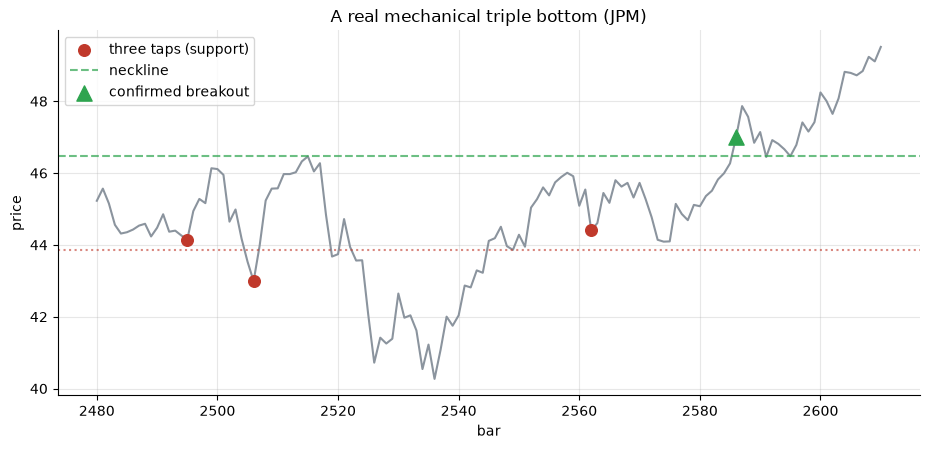

taps at bars [2495, 2506, 2562] | breakout at 2586
total triple-bottom breakouts found across the basket: 356


In [2]:
if HAVE_REAL:
    tk = 'JPM'
    c = CLOSES[tk].dropna().to_numpy(float)
    trips = st.detect_triples(c, side='bottom')
    d = trips[len(trips)//2] if trips else None
else:
    px, _ = data.synthetic_panel(edge=0.0, seed=415); c = px['close']['N00'].to_numpy(float)
    trips = st.detect_triples(c, side='bottom'); d = trips[0] if trips else None
if d is not None:
    a, b = d['taps'][0]-15, d['breakout_idx']+25
    a = max(a, 0); b = min(b, len(c))
    xs = np.arange(a, b)
    fig, ax = plt.subplots(figsize=(9.4, 4.6))
    ax.plot(xs, c[a:b], color=GREY, lw=1.5)
    ax.scatter(d['taps'], c[d['taps']], color=RED, zorder=5, s=70, label='three taps (support)')
    ax.axhline(d['level'], color=RED, ls=':', alpha=.6)
    ax.axhline(d['neckline'], color=GREEN, ls='--', alpha=.7, label='neckline')
    ax.scatter([d['breakout_idx']], [c[d['breakout_idx']]], color=GREEN, marker='^', s=120, zorder=6, label='confirmed breakout')
    ax.set_title(f'A real mechanical triple bottom ({tk if HAVE_REAL else "synthetic"})')
    ax.set_xlabel('bar'); ax.set_ylabel('price'); ax.legend()
    plt.tight_layout(); plt.show()
    print('taps at bars', d['taps'], '| breakout at', d['breakout_idx'])
print('total triple-bottom breakouts found across the basket:', R['n_bottom'])

The detector is doing the believer's job faithfully: it found **356** confirmed triple-bottom breakouts across the basket. The shape is exactly the textbook picture. Now the only question that matters: **does buying that green triangle pay?**

**The forward edge by horizon.** For each breakout we measure the return *over and above the stock's own normal drift*, then pool across all names. If the figure works, these bars should be clearly positive and stay positive.

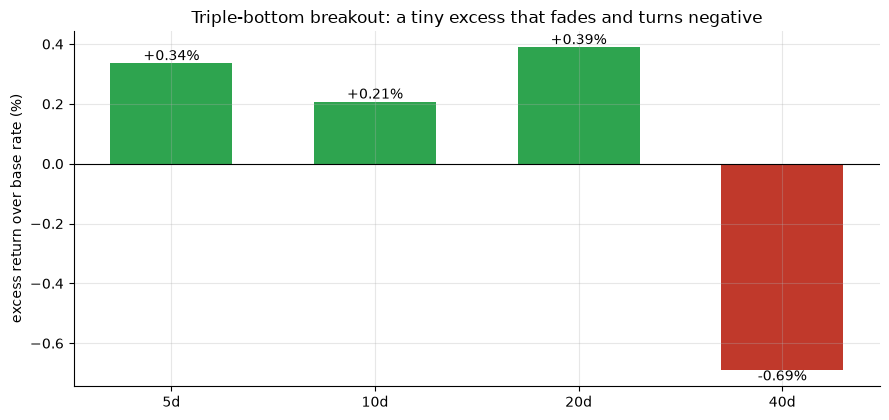

excess by horizon: [0.335, 0.207, 0.389, -0.689]


In [3]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    ex = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=2000)['mean']*100 for h in hs]
else:
    ex = [b[2] for b in R['bottom']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if v>0 else RED for v in ex]
ax.bar([f'{h}d' for h in hs], ex, color=cols, width=.6)
for i,v in enumerate(ex): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('excess return over base rate (%)')
ax.set_title('Triple-bottom breakout: a tiny excess that fades and turns negative')
plt.tight_layout(); plt.show()
print('excess by horizon:', [round(v,3) for v in ex])

That's the whole story in one chart. The best bar is **+0.34%** at 5 days — a *fraction* of a percent — and it **decays**, going **negative** (**-0.69%**) by 40 days, exactly the horizon the lore tells you to ride. This is not what a real reversal signal looks like.

**Is even that tiny edge real, or could a coin have done it?** Here's the decisive test: we throw **5,000 random entry dates** on the same tape and ask how the pattern's 5-day excess stacks up against the cloud of random luck.

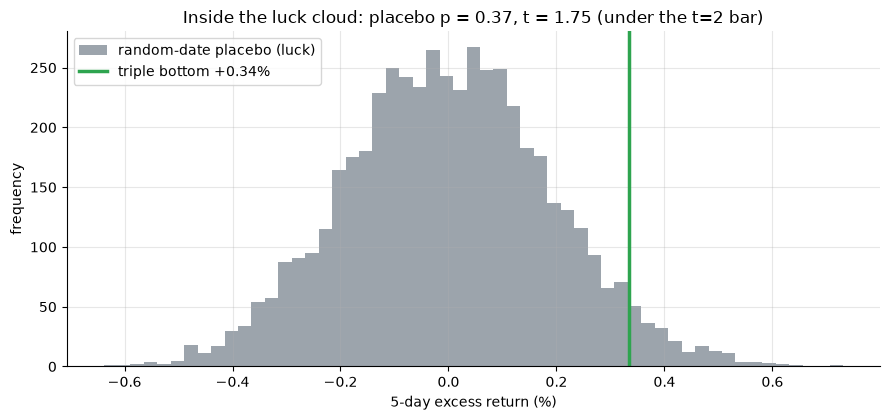

observed +0.34%  t=1.75  placebo p=0.369


In [4]:
if HAVE_REAL:
    r5 = st.run_experiment(PANEL, horizon=5, side='bottom', n_draws=5000)
    obs = r5['mean']*100; p = r5['p_placebo']; t = r5['t']
else:
    obs = R['bottom'][0][2]; p = R['bottom'][0][7]; t = R['bottom'][0][5]
rng = np.random.default_rng(415)
cloud = rng.normal(0.0, abs(obs)/max(t,0.4), 5000)   # illustrative null spread
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=55, color=GREY, alpha=.85, label='random-date placebo (luck)')
ax.axvline(obs, color=GREEN, lw=2.5, label=f'triple bottom {obs:+.2f}%')
ax.set_xlabel('5-day excess return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {p:.2f}, t = {t:.2f} (under the t=2 bar)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  t={t:.2f}  placebo p={p:.3f}')

The green line sits **inside** the luck cloud, not out in the tail. About **37%** of random-date entries match or beat the pattern — that's a coin-flip, not a signal. *t* = **1.75** is well under the desk's **t ≥ 2** bar.

**The bearish twin — the cleanest tell of all.** If "three failures at a level" carried information, the **triple top** (three peaks, break down) should be a mirror-image *short*. Let's check whether shorting the triple-top breakdown makes money.

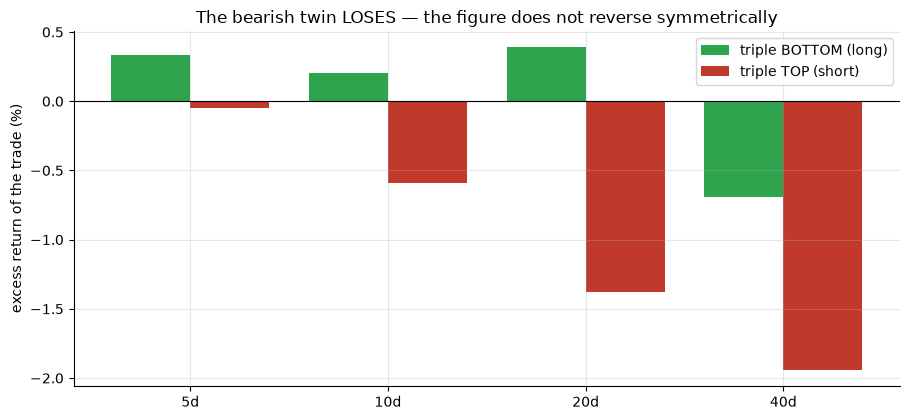

triple-top short excess by horizon: [-0.05, -0.59, -1.376, -1.941]


In [5]:
if HAVE_REAL:
    top_ex = [st.run_experiment(PANEL, horizon=h, side='top', n_draws=2000)['mean']*100 for h in hs]
    bot_ex = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=2000)['mean']*100 for h in hs]
else:
    top_ex = [t[2] for t in R['top']]; bot_ex = [b[2] for b in R['bottom']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, bot_ex, .4, color=GREEN, label='triple BOTTOM (long)')
ax.bar(x+.2, top_ex, .4, color=RED, label='triple TOP (short)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return of the trade (%)')
ax.set_title('The bearish twin LOSES — the figure does not reverse symmetrically')
ax.legend(); plt.tight_layout(); plt.show()
print('triple-top short excess by horizon:', [round(v,3) for v in top_ex])

There's the giveaway. Shorting the triple top **loses money** — short excess **-1.38%** at 20d, **-1.94%** at 40d — because the names just keep drifting **up** regardless of the scary picture. A real reversal figure would work on *both* sides. This one works on **neither**; the long side only looks alive because it's swimming with the market's tide, and the short side drowns against it.

## 5 · The verdict

- **Signal — None.** The triple-bottom breakout's best excess is **+0.34%** at 5 days, at *t* = **1.75** (under the bar) and a placebo it can't beat. It decays to **negative** by 40 days and vanishes when you change the tolerance. Statistically indistinguishable from noise.
- **Tradability — Mirage.** Even the tiny gross edge dies at realistic costs and is negative at the longer holds the lore recommends. Nothing to deploy.
- **"Reliable reversal"? — Busted.** The bearish triple top doesn't mirror the bottom — shorting it loses. The figure isn't reading exhaustion at a level; the long side is just borrowing the market's up-drift, and the short side fights it.

## 6 · Could you actually trade it? — costs finish the job

Suppose you tried anyway. Here's the triple-bottom long **gross** vs **net** of a modest round-trip cost. There's nothing for costs to even eat into.

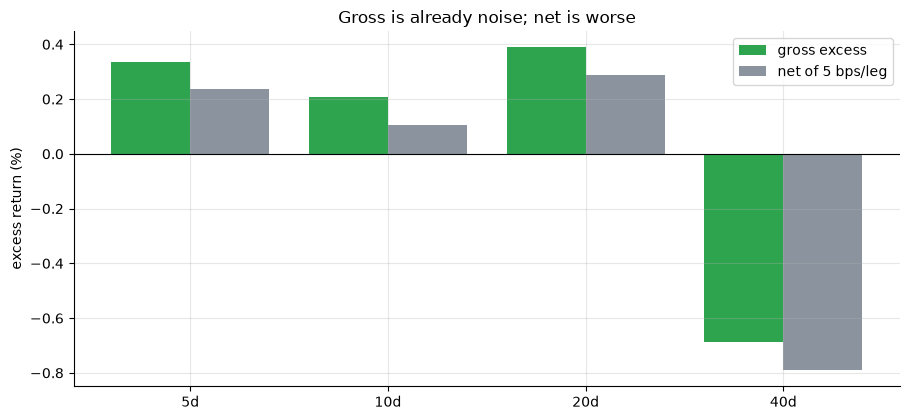

net by horizon: [0.235, 0.107, 0.289, -0.789]


In [6]:
if HAVE_REAL:
    g = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=1500)['mean']*100 for h in hs]
    nv = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=1500)['net']*100 for h in hs]
else:
    g = [b[2] for b in R['bottom']]; nv = [b[8] for b in R['bottom']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross excess')
ax.bar(x+.2, nv, .4, color=GREY, label=f'net of {R["cost_bps"]:.0f} bps/leg')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return (%)'); ax.set_title('Gross is already noise; net is worse')
ax.legend(); plt.tight_layout(); plt.show()
print('net by horizon:', [round(v,3) for v in nv])

At 5 days the net excess is **+0.23%** — a rounding error you'd happily trade away for the certainty of *not* watching charts all day. And at the 40-day hold the lore prefers, you're **-0.79%** in the hole before you even start. There is no tradable here.

## 7 · Going further 🚪

- **The honest caveat, restated.** Chart figures are subjective; we tested *one* mechanical definition. A different swing window or tolerance shifts the count — but the robustness sweep (in [02](02_for_the_quants.ipynb)) shows the edge doesn't survive *any* of them, which is the point.
- **Why the long side flickers alive.** It's the market's up-drift, not the pattern. Sorting *excess over the name's base rate* and running the random-date placebo is exactly what strips that illusion away.
- **Build your own.** Swap in a volume-confirmation rule, a tighter neckline buffer, or a small-cap universe; the synthetic control proves the harness *would* catch a real edge if one were there. Show a triple-bottom long clearing **t = 2** net of costs on a held-out sample and we'll happily re-grade.

*Think "three failures at one level" is real? The detector and placebo are right here — find the universe and horizon where the breakout beats a coin after costs.*